In [1]:
# ===== Cell 1: 强制只使用 GPU 0（必须放在最前面） =====
import os

# 这两行必须在 import torch / import nichecompass 之前
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
print("现在 notebook 只会看到 1 块 GPU，并且它对应物理 GPU 0")

CUDA_VISIBLE_DEVICES = 0
现在 notebook 只会看到 1 块 GPU，并且它对应物理 GPU 0


In [2]:
# ===== Cell 2: 验证 GPU 是否锁定成功 =====
import sys
import torch

LOCAL_SRC = "/home/zhangjunyi/xiangmu/nichecompass-main/src"
if LOCAL_SRC not in sys.path:
    sys.path.insert(0, LOCAL_SRC)

import nichecompass as nc

print("nichecompass loaded from:")
print(nc.__file__)

print("\ntorch.cuda.is_available() =", torch.cuda.is_available())
print("torch.cuda.device_count() =", torch.cuda.device_count())

if torch.cuda.is_available():
    print("当前可见 GPU 名称 =", torch.cuda.get_device_name(0))
    print("当前可见 GPU 编号 = 0")
else:
    print("没有检测到 GPU，说明前面环境或内核有问题。")

assert nc.__file__.startswith("/home/zhangjunyi/xiangmu/nichecompass-main/src"), \
    "当前导入的不是你本地修改后的 NicheCompass，请先重启 kernel 再运行。"

nichecompass loaded from:
/home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
当前可见 GPU 名称 = A100 80GB PCIe
当前可见 GPU 编号 = 0


Cell 1：确保导入的是你本地修改版 NicheCompass

In [3]:
import sys
sys.path.insert(0, "/home/zhangjunyi/xiangmu/nichecompass-main/src")

import nichecompass as nc
print(nc.__file__)

/home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py


Cell 2：导入依赖 + 定义四元组

In [4]:
# ===== Cell 2: 依赖 + 四元组 =====
import warnings
warnings.filterwarnings("ignore")

from io import StringIO
from pathlib import Path

import decoupler as dc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import squidpy as sq
import torch
from sklearn.preprocessing import MinMaxScaler

tmcn_csv = """TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
TMCN_Lactate_Axis,"EGFR,PI3K,Hypoxia","HK2,LDHA,LDHB,SLC16A3","SLC16A1,HCAR1",乳酸_肿瘤酸化与代谢重生
TMCN_Adenosine_Axis,"Hypoxia","MYC,ENTPD1,NT5E","ADORA1,ADORA2A,ADORA2B,ADORA3",腺苷_强效免疫抑制与血管生成
TMCN_PGE2_Axis,"NFkB,JAK-STAT","PTGS2,PTGES","PTGER1,PTGER2,PTGER4",前列腺素E2_炎症微环境重塑
TMCN_Glutamine_Axis,"JAK-STAT,TGFb","MYC,GLUL","SLC1A5,SLC38A2",谷氨酰胺_基质-肿瘤代谢共生(寄生)
TMCN_Succinate_Axis,"Hypoxia","EGLN1,TET2,SLC25A10","SUCNR1",琥珀酸_琥珀酸介导的巨噬细胞极化
"""

tmcn_df = pd.read_csv(StringIO(tmcn_csv))
display(tmcn_df)

AXES = [x.replace("TMCN_", "").replace("_Axis", "") for x in tmcn_df["TMCN_Name"].tolist()]
print("Axes:", AXES)

,TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
0,TMCN_Lactate_Axis,"EGFR,PI3K,Hypoxia","HK2,LDHA,LDHB,SLC16A3","SLC16A1,HCAR1",乳酸_肿瘤酸化与代谢重生
1,TMCN_Adenosine_Axis,Hypoxia,"MYC,ENTPD1,NT5E","ADORA1,ADORA2A,ADORA2B,ADORA3",腺苷_强效免疫抑制与血管生成
2,TMCN_PGE2_Axis,"NFkB,JAK-STAT","PTGS2,PTGES","PTGER1,PTGER2,PTGER4",前列腺素E2_炎症微环境重塑
3,TMCN_Glutamine_Axis,"JAK-STAT,TGFb","MYC,GLUL","SLC1A5,SLC38A2",谷氨酰胺_基质-肿瘤代谢共生(寄生)
4,TMCN_Succinate_Axis,Hypoxia,"EGLN1,TET2,SLC25A10",SUCNR1,琥珀酸_琥珀酸介导的巨噬细胞极化


Axes: ['Lactate', 'Adenosine', 'PGE2', 'Glutamine', 'Succinate']


Cell 3：工具函数

In [26]:
# ===== Cell 3: 工具函数（最终稳定版，不再使用 scanpy HVG） =====

def split_items(x):
    return [i.strip() for i in str(x).split(",") if i.strip()]

def normalize_pathway_name(x):
    return x.strip().replace("-", "_").replace(" ", "_")

def get_valid_genes(adata, genes):
    return [g for g in genes if g in adata.var_names]

def sparse_or_dense_mean_by_genes(adata, genes):
    """
    计算一组基因在每个 spot/cell 中的平均表达。
    支持 sparse / dense。
    """
    valid_genes = get_valid_genes(adata, genes)
    if len(valid_genes) == 0:
        return np.zeros(adata.n_obs, dtype=float)

    X = adata[:, valid_genes].X
    if sp.issparse(X):
        return np.asarray(X.mean(axis=1)).reshape(-1)
    return np.asarray(X).mean(axis=1).reshape(-1)

def minmax_1d(x):
    x = np.asarray(x).reshape(-1, 1)
    return MinMaxScaler().fit_transform(x).reshape(-1)

def build_metabolic_net_from_quartets(tmcn_df, adata):
    """
    把四元组中的 Source_Genes 构造成 AUCell 需要的网络格式。
    """
    rows = []
    for _, row in tmcn_df.iterrows():
        axis = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
        for g in split_items(row["Source_Genes"]):
            if g in adata.var_names:
                rows.append({"source": axis, "target": g})
    return pd.DataFrame(rows)

def collect_forced_genes(tmcn_df):
    """
    收集必须保留的四元组基因：
    Source_Genes ∪ Target_Genes
    """
    forced = set()
    for _, row in tmcn_df.iterrows():
        forced.update(split_items(row["Source_Genes"]))
        forced.update(split_items(row["Target_Genes"]))
    return forced

def compute_tmcn_scores(adata_full, tmcn_df):
    """
    阶段 1：在全量 adata 上计算：
    1. PROGENy pathway activity
    2. AUCell machinery activity
    3. Sender / Receiver 综合得分
    """
    # ---------- 步骤 1.1：PROGENy ----------
    net_progeny = dc.get_progeny(organism="human", top=500)
    dc.run_mlm(
        mat=adata_full,
        net=net_progeny,
        source="source",
        target="target",
        weight="weight",
        verbose=False,
        use_raw=False,
    )

    df_A = dc.get_acts(adata_full, obsm_key="mlm_estimate").to_df()
    df_A.columns = [f"PROGENy_{normalize_pathway_name(c)}" for c in df_A.columns]

    # ---------- 步骤 1.2：AUCell ----------
    metabolic_net = build_metabolic_net_from_quartets(tmcn_df, adata_full)
    dc.run_aucell(
        mat=adata_full,
        net=metabolic_net,
        source="source",
        target="target",
        min_n=1,
        verbose=False,
        use_raw=False,
    )

    df_B = dc.get_acts(adata_full, obsm_key="aucell_estimate").to_df()
    df_B.columns = [f"AUCell_{c}" for c in df_B.columns]

    # ---------- 步骤 1.3：归一化 ----------
    df_A_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df_A),
        index=df_A.index,
        columns=df_A.columns
    )

    df_B_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df_B),
        index=df_B.index,
        columns=df_B.columns
    )

    # ---------- 计算 Sender / Receiver ----------
    for _, row in tmcn_df.iterrows():
        axis = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
        source_pathways = [normalize_pathway_name(x) for x in split_items(row["Source_Pathways"])]
        target_genes = split_items(row["Target_Genes"])

        progeny_cols = [f"PROGENy_{p}" for p in source_pathways if f"PROGENy_{p}" in df_A_scaled.columns]
        aucell_col = f"AUCell_{axis}"

        if len(progeny_cols) == 0:
            raise ValueError(f"{axis}: 没找到 PROGENy 列，请检查 Source_Pathways 名称。")

        if aucell_col not in df_B_scaled.columns:
            raise ValueError(f"{axis}: 没找到 AUCell 列 {aucell_col}。")

        sender_score = df_A_scaled[progeny_cols].mean(axis=1) * df_B_scaled[aucell_col]
        receiver_score = minmax_1d(sparse_or_dense_mean_by_genes(adata_full, target_genes))

        adata_full.obs[f"{axis}_Sender_Score"] = sender_score.values
        adata_full.obs[f"{axis}_Receiver_Score"] = receiver_score

    return adata_full, df_A, df_B, df_A_scaled, df_B_scaled


# =========================
# 新增：稳定的矩阵清洗函数
# =========================
def sanitize_matrix(mat):
    """
    把矩阵中的 nan / inf 清理掉。
    """
    if sp.issparse(mat):
        mat = mat.copy().tocsr()
        mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
        return mat
    else:
        return np.nan_to_num(np.asarray(mat), nan=0.0, posinf=0.0, neginf=0.0)

def get_matrix_for_hvg(adata):
    """
    优先使用 counts layer；
    如果没有，就使用 X。
    返回清洗后的矩阵和来源名字。
    """
    if "counts" in adata.layers:
        X = sanitize_matrix(adata.layers["counts"])
        source_name = "counts"
    else:
        X = sanitize_matrix(adata.X)
        source_name = "X"
    return X, source_name

def compute_gene_dispersion_manual(X):
    """
    手动计算每个基因的离散度（dispersion），避免 scanpy HVG 的 binning 报错。
    dispersion = variance / mean
    """
    if sp.issparse(X):
        X = X.tocsr()
        gene_mean = np.asarray(X.mean(axis=0)).reshape(-1)
        gene_mean_sq = np.asarray(X.multiply(X).mean(axis=0)).reshape(-1)
        gene_var = gene_mean_sq - gene_mean ** 2
    else:
        gene_mean = np.mean(X, axis=0)
        gene_var = np.var(X, axis=0)

    gene_mean = np.nan_to_num(gene_mean, nan=0.0, posinf=0.0, neginf=0.0)
    gene_var = np.nan_to_num(gene_var, nan=0.0, posinf=0.0, neginf=0.0)

    # 防止负数方差（数值误差）
    gene_var = np.maximum(gene_var, 0.0)

    # dispersion = variance / mean
    dispersion = gene_var / (gene_mean + 1e-8)
    dispersion = np.nan_to_num(dispersion, nan=0.0, posinf=0.0, neginf=0.0)

    return gene_mean, gene_var, dispersion

def select_top_hvg_manual(adata, n_top_genes=2000):
    """
    手动选择 HVG：
    - 不使用 scanpy.pp.highly_variable_genes
    - 直接按 dispersion 排名前 n_top_genes
    """
    X_hvg, source_name = get_matrix_for_hvg(adata)
    gene_mean, gene_var, dispersion = compute_gene_dispersion_manual(X_hvg)

    df_stats = pd.DataFrame({
        "gene": adata.var_names,
        "mean": gene_mean,
        "var": gene_var,
        "dispersion": dispersion
    })

    # 去掉完全无信息的基因
    df_stats = df_stats[(df_stats["mean"] >= 0) & np.isfinite(df_stats["dispersion"])].copy()

    # 按 dispersion 从大到小选前 n_top_genes
    df_stats = df_stats.sort_values("dispersion", ascending=False)
    hvg_genes = df_stats["gene"].head(n_top_genes).tolist()

    print(f"HVG 来源矩阵: {source_name}")
    print(f"可用于排序的基因数: {df_stats.shape[0]}")
    print(f"选出的 HVG 数: {len(hvg_genes)}")

    return set(hvg_genes), df_stats

def subset_hvg_plus_quartet_genes(adata_full, tmcn_df, n_top_genes=2000):
    """
    训练用基因子集：
    HVG(2000) ∪ 四元组基因
    """
    forced_genes = collect_forced_genes(tmcn_df)
    forced_genes = {g for g in forced_genes if g in adata_full.var_names}

    hvg_genes, df_hvg_stats = select_top_hvg_manual(adata_full, n_top_genes=n_top_genes)

    keep_genes = sorted(hvg_genes.union(forced_genes))
    adata_model = adata_full[:, keep_genes].copy()

    # 再清一次，确保模型输入无坏值
    adata_model.X = sanitize_matrix(adata_model.X)
    if "counts" in adata_model.layers:
        adata_model.layers["counts"] = sanitize_matrix(adata_model.layers["counts"])

    print(f"原始基因数: {adata_full.n_vars}")
    print(f"手动HVG数: {len(hvg_genes)}")
    print(f"强制保留四元组基因数: {len(forced_genes)}")
    print(f"最终训练基因数: {adata_model.n_vars}")

    if sp.issparse(adata_model.X):
        n_bad_x = np.sum(~np.isfinite(adata_model.X.data))
    else:
        n_bad_x = np.sum(~np.isfinite(np.asarray(adata_model.X)))
    print(f"adata_model.X 中非有限值个数: {int(n_bad_x)}")

    if "counts" in adata_model.layers:
        if sp.issparse(adata_model.layers["counts"]):
            n_bad_counts = np.sum(~np.isfinite(adata_model.layers["counts"].data))
        else:
            n_bad_counts = np.sum(~np.isfinite(np.asarray(adata_model.layers["counts"])))
        print(f"adata_model.layers['counts'] 中非有限值个数: {int(n_bad_counts)}")

    return adata_model, keep_genes, df_hvg_stats

def build_tmcn_graph(adata_model, axes, n_neighs=8):
    """
    阶段 2.2：构建代谢加权空间图
    """
    sq.gr.spatial_neighbors(
        adata_model,
        coord_type="generic",
        spatial_key="spatial",
        n_neighs=n_neighs
    )

    spatial_adj = adata_model.obsp["spatial_connectivities"].tocsr()

    S = np.vstack([adata_model.obs[f"{axis}_Sender_Score"].to_numpy() for axis in axes]).T
    R = np.vstack([adata_model.obs[f"{axis}_Receiver_Score"].to_numpy() for axis in axes]).T

    row_idx, col_idx = spatial_adj.nonzero()
    base_weights = np.asarray(spatial_adj[row_idx, col_idx]).reshape(-1)

    metabolic_affinity = np.sum(S[row_idx] * R[col_idx], axis=1)
    edge_weights = np.clip(base_weights * metabolic_affinity, a_min=1e-6, a_max=None)

    tmcn_adj = sp.csr_matrix(
        (edge_weights, (row_idx, col_idx)),
        shape=spatial_adj.shape
    )

    adata_model.obsp["tmcn_connectivities"] = tmcn_adj.maximum(tmcn_adj.T)
    return adata_model

def load_or_download_nichenet_cache(cache_dir):
    """
    读取或下载 NicheNet 先验，并缓存到本地。
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    lr_path = cache_dir / "nichenet_lr_network.csv"
    lt_path = cache_dir / "nichenet_ligand_target_matrix.csv"

    if lr_path.exists() and lt_path.exists():
        print("从本地缓存加载 NicheNet...")
        gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
            species="human",
            version="v2",
            keep_target_genes_ratio=0.25,
            max_n_target_genes_per_gp=50,
            load_from_disk=True,
            lr_network_file_path=str(lr_path),
            ligand_target_matrix_file_path=str(lt_path),
            plot_gp_gene_count_distributions=False,
        )
    else:
        print("首次下载并缓存 NicheNet...")
        gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
            species="human",
            version="v2",
            keep_target_genes_ratio=0.25,
            max_n_target_genes_per_gp=50,
            save_to_disk=True,
            lr_network_file_path=str(lr_path),
            ligand_target_matrix_file_path=str(lt_path),
            plot_gp_gene_count_distributions=False,
        )
    return gp_dict

def annotate_tmcn_clusters(adata_model, axes, cluster_key="TMCN_Clusters", threshold=0.05):
    """
    阶段 3.2：根据 Sender*Receiver 强度给 cluster 打标签
    """
    rows = []
    for cluster in adata_model.obs[cluster_key].cat.categories:
        mask = adata_model.obs[cluster_key] == cluster
        row = {"Cluster": cluster}
        for axis in axes:
            intensity = (
                adata_model.obs.loc[mask, f"{axis}_Sender_Score"] *
                adata_model.obs.loc[mask, f"{axis}_Receiver_Score"]
            ).mean()
            row[f"{axis}_Intensity"] = intensity
        rows.append(row)

    df_cluster = pd.DataFrame(rows).set_index("Cluster")

    def label_cluster(row):
        best_axis = row.idxmax().replace("_Intensity", "")
        best_val = row.max()
        if best_val > threshold:
            return f"TMCN_{best_axis}_Axis"
        return "Background/Other_Niche"

    df_cluster["TMCN_Annotation"] = df_cluster.apply(label_cluster, axis=1)
    adata_model.obs["TMCN_Niche"] = adata_model.obs[cluster_key].map(
        df_cluster["TMCN_Annotation"].to_dict()
    )
    return adata_model, df_cluster

这套代码一共做 5 件事：

get_quantile_thresholds()
计算每条 axis 的 sender / receiver 分位数阈值

assign_spot_roles_by_axis()
给每个 spot 赋角色：Sender / Receiver / 既是Sender也是Receiver Dual / None

summarize_cluster_axis_composition()
统计每个 cluster 在每条 axis 上的组成比例和均值

compute_cluster_axis_composition_score()
算综合分数

assign_cluster_tmcn_labels()
给 cluster 打主标签 / 次标签 / 模式标签

In [27]:
# ===== 新版 TMCN 注释工具函数：基于 spot 角色组成的 cluster 注释 =====

def get_quantile_thresholds(adata, axes, sender_q=0.75, receiver_q=0.75, min_positive=1e-8):
    """
    为每条 axis 计算 sender / receiver 的分位数阈值。
    只在 > min_positive 的正值上计算分位数，避免阈值变成 0。
    """

    thresholds = {}

    for axis in axes:
        sender_col = f"{axis}_Sender_Score"
        receiver_col = f"{axis}_Receiver_Score"

        sender_vals = adata.obs[sender_col].values
        receiver_vals = adata.obs[receiver_col].values

        sender_pos = sender_vals[sender_vals > min_positive]
        receiver_pos = receiver_vals[receiver_vals > min_positive]

        if len(sender_pos) == 0:
            sender_thr = np.inf
        else:
            sender_thr = float(np.quantile(sender_pos, sender_q))

        if len(receiver_pos) == 0:
            receiver_thr = np.inf
        else:
            receiver_thr = float(np.quantile(receiver_pos, receiver_q))

        thresholds[axis] = {
            "sender": sender_thr,
            "receiver": receiver_thr
        }

    return thresholds


def assign_spot_roles_by_axis(adata, axes, thresholds, min_positive=1e-8):
    """
    对每个 spot、每条 axis 赋予角色:
        Sender / Receiver / Dual / None
    并要求 score 本身也必须 > min_positive，防止 0 被判成高值。
    """
    for axis in axes:
        sender_col = f"{axis}_Sender_Score"
        receiver_col = f"{axis}_Receiver_Score"
        role_col = f"{axis}_Role"

        sender_thr = thresholds[axis]["sender"]
        receiver_thr = thresholds[axis]["receiver"]

        sender_vals = adata.obs[sender_col].values
        receiver_vals = adata.obs[receiver_col].values

        sender_high = (sender_vals > min_positive) & (sender_vals >= sender_thr)
        receiver_high = (receiver_vals > min_positive) & (receiver_vals >= receiver_thr)

        roles = np.full(adata.n_obs, "None", dtype=object)
        roles[np.where(sender_high & ~receiver_high)[0]] = "Sender"
        roles[np.where(~sender_high & receiver_high)[0]] = "Receiver"
        roles[np.where(sender_high & receiver_high)[0]] = "Dual"

        adata.obs[role_col] = pd.Categorical(
            roles,
            categories=["None", "Sender", "Receiver", "Dual"]
        )

    return adata

def summarize_cluster_axis_composition(adata, axes, cluster_key="TMCN_Clusters"):
    """
    统计每个 cluster 在每条 axis 上的组成信息:
        - Sender_Fraction
        - Receiver_Fraction
        - Dual_Fraction
        - Sender_Mean
        - Receiver_Mean
        - Mean_Intensity = mean(Sender * Receiver)

    返回:
        df_summary: 每个 cluster x axis 的详细表
    """
    rows = []

    clusters = adata.obs[cluster_key].cat.categories \
        if pd.api.types.is_categorical_dtype(adata.obs[cluster_key]) \
        else sorted(adata.obs[cluster_key].unique())

    for cluster in clusters:
        mask = adata.obs[cluster_key] == cluster
        n_spots = int(mask.sum())

        for axis in axes:
            sender_col = f"{axis}_Sender_Score"
            receiver_col = f"{axis}_Receiver_Score"
            role_col = f"{axis}_Role"

            sender_scores = adata.obs.loc[mask, sender_col]
            receiver_scores = adata.obs.loc[mask, receiver_col]
            roles = adata.obs.loc[mask, role_col]

            sender_fraction = float((roles == "Sender").mean()) if n_spots > 0 else 0.0
            receiver_fraction = float((roles == "Receiver").mean()) if n_spots > 0 else 0.0
            dual_fraction = float((roles == "Dual").mean()) if n_spots > 0 else 0.0
            none_fraction = float((roles == "None").mean()) if n_spots > 0 else 0.0

            sender_mean = float(sender_scores.mean()) if n_spots > 0 else 0.0
            receiver_mean = float(receiver_scores.mean()) if n_spots > 0 else 0.0
            mean_intensity = float((sender_scores * receiver_scores).mean()) if n_spots > 0 else 0.0

            rows.append({
                "Cluster": cluster,
                "Axis": axis,
                "N_Spots": n_spots,
                "Sender_Fraction": sender_fraction,
                "Receiver_Fraction": receiver_fraction,
                "Dual_Fraction": dual_fraction,
                "None_Fraction": none_fraction,
                "Sender_Mean": sender_mean,
                "Receiver_Mean": receiver_mean,
                "Mean_Intensity": mean_intensity
            })

    df_summary = pd.DataFrame(rows)
    return df_summary


def compute_cluster_axis_composition_score(
    df_summary,
    w_sender=0.35,
    w_receiver=0.35,
    w_dual=0.20,
    w_intensity=0.10
):
    """
    基于组成与强度计算每个 cluster-axis 的综合得分。
    """
    df_summary = df_summary.copy()

    df_summary["Axis_Composition_Score"] = (
        w_sender * df_summary["Sender_Fraction"] +
        w_receiver * df_summary["Receiver_Fraction"] +
        w_dual * df_summary["Dual_Fraction"] +
        w_intensity * df_summary["Mean_Intensity"]
    )

    return df_summary


def assign_cluster_tmcn_labels(
    adata,
    df_summary,
    cluster_key="TMCN_Clusters",
    score_col="Axis_Composition_Score",
    min_score_threshold=0.12,
    min_margin=0.02
):
    """
    为每个 cluster 指定主标签 / 次标签。

    规则:
    1. 对每个 cluster，按 Axis_Composition_Score 从高到低排序
    2. 最高分若 < min_score_threshold -> Background/Other_Niche
    3. 若第一名和第二名差距 < min_margin，也标成 Mixed_or_Ambiguous_Niche
       （你也可以以后改成主次双标签）
    4. 否则标成 TMCN_{best_axis}_Axis

    新增到 adata.obs 的列:
        - TMCN_Niche_v2
        - TMCN_Main_Axis
        - TMCN_Secondary_Axis
        - TMCN_Niche_Pattern
    """
    cluster_label_map = {}
    cluster_main_axis_map = {}
    cluster_second_axis_map = {}
    cluster_pattern_map = {}

    cluster_tables = []

    for cluster, sub in df_summary.groupby("Cluster"):
        sub = sub.sort_values(score_col, ascending=False).reset_index(drop=True)

        best_axis = sub.loc[0, "Axis"]
        best_score = float(sub.loc[0, score_col])

        if sub.shape[0] > 1:
            second_axis = sub.loc[1, "Axis"]
            second_score = float(sub.loc[1, score_col])
        else:
            second_axis = "None"
            second_score = 0.0

        margin = best_score - second_score

        # 判断这个 cluster 的模式
        best_sender_frac = float(sub.loc[0, "Sender_Fraction"])
        best_receiver_frac = float(sub.loc[0, "Receiver_Fraction"])
        best_dual_frac = float(sub.loc[0, "Dual_Fraction"])

        if best_dual_frac >= max(best_sender_frac, best_receiver_frac):
            niche_pattern = "Dual_Dominant"
        elif best_sender_frac > best_receiver_frac:
            niche_pattern = "Sender_Dominant"
        elif best_receiver_frac > best_sender_frac:
            niche_pattern = "Receiver_Dominant"
        else:
            niche_pattern = "Balanced"

        if best_score < min_score_threshold:
            niche_label = "Background/Other_Niche"
        elif margin < min_margin:
            niche_label = f"Mixed_or_Ambiguous_{best_axis}_Axis"
        else:
            niche_label = f"TMCN_{best_axis}_Axis"

        cluster_label_map[cluster] = niche_label
        cluster_main_axis_map[cluster] = best_axis
        cluster_second_axis_map[cluster] = second_axis
        cluster_pattern_map[cluster] = niche_pattern

        sub["Best_Axis"] = best_axis
        sub["Best_Score"] = best_score
        sub["Second_Axis"] = second_axis
        sub["Second_Score"] = second_score
        sub["Score_Margin"] = margin
        sub["Assigned_Label"] = niche_label
        sub["Niche_Pattern"] = niche_pattern
        cluster_tables.append(sub)

    df_cluster_annotation = pd.concat(cluster_tables, axis=0)

    adata.obs["TMCN_Niche_v2"] = adata.obs[cluster_key].map(cluster_label_map)
    adata.obs["TMCN_Main_Axis"] = adata.obs[cluster_key].map(cluster_main_axis_map)
    adata.obs["TMCN_Secondary_Axis"] = adata.obs[cluster_key].map(cluster_second_axis_map)
    adata.obs["TMCN_Niche_Pattern"] = adata.obs[cluster_key].map(cluster_pattern_map)

    return adata, df_cluster_annotation


def build_cluster_wide_table(df_cluster_annotation):
    """
    把长表转成更方便看的 cluster 汇总表:
        每个 cluster 只保留一行
    """
    keep_cols = [
        "Cluster",
        "Best_Axis",
        "Best_Score",
        "Second_Axis",
        "Second_Score",
        "Score_Margin",
        "Assigned_Label",
        "Niche_Pattern"
    ]

    df_cluster_wide = (
        df_cluster_annotation[keep_cols]
        .drop_duplicates()
        .sort_values(["Assigned_Label", "Best_Score"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return df_cluster_wide

Cell 4：阶段 1，全量打分

In [28]:
# ===== Cell 4: 阶段1 - 全量打分 =====
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"
adata_full = sc.read_h5ad(file_path)

print(adata_full)
print("has counts layer:", "counts" in adata_full.layers)
print("has spatial coords:", "spatial" in adata_full.obsm)

adata_full, df_A, df_B, df_A_scaled, df_B_scaled = compute_tmcn_scores(adata_full, tmcn_df)

score_cols = [c for c in adata_full.obs.columns if c.endswith("_Score")]
display(adata_full.obs[score_cols].describe().T)

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
has counts layer: False
has spatial coords: True


,count,mean,std,min,25%,50%,75%,max
Lactate_Sender_Score,3798.0,0.127916,0.074464,0.0,0.089275,0.122083,0.160193,0.557291
Lactate_Receiver_Score,3798.0,0.100777,0.138558,0.0,0.000000,0.000000,0.125000,1.000000
Adenosine_Sender_Score,3798.0,0.020091,0.037005,0.0,0.000000,0.000000,0.030086,0.377811
Adenosine_Receiver_Score,3798.0,0.169061,0.162829,0.0,0.047619,0.142857,0.238095,1.000000
PGE2_Sender_Score,3798.0,0.023789,0.076771,0.0,0.000000,0.000000,0.000000,0.569351
PGE2_Receiver_Score,3798.0,0.059110,0.130944,0.0,0.000000,0.000000,0.000000,1.000000
Glutamine_Sender_Score,3798.0,0.096796,0.057907,0.0,0.060777,0.094363,0.129142,0.384487
Glutamine_Receiver_Score,3798.0,0.165751,0.133950,0.0,0.071429,0.142857,0.238095,1.000000
Succinate_Sender_Score,3798.0,0.007008,0.026770,0.0,0.000000,0.000000,0.000000,0.381174
Succinate_Receiver_Score,3798.0,0.012375,0.068375,0.0,0.000000,0.000000,0.000000,1.000000


Cell 5：构建练用 adata_model（2000 HVG + 四元组基因）

In [29]:
# ===== Cell 5: HVG + 四元组基因子集 =====
adata_model, keep_genes, df_hvg_stats = subset_hvg_plus_quartet_genes(
    adata_full,
    tmcn_df,
    n_top_genes=2000
)

print(adata_model)
display(df_hvg_stats.head(20))

HVG 来源矩阵: X
可用于排序的基因数: 36601
选出的 HVG 数: 2000
原始基因数: 36601
手动HVG数: 2000
强制保留四元组基因数: 25
最终训练基因数: 2017
adata_model.X 中非有限值个数: 0
AnnData object with n_obs × n_vars = 3798 × 2017
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type', 'Lactate_Sender_Score', 'Lactate_Receiver_Score', 'Adenosine_Sender_Score', 'Adenosine_Receiver_Score', 'PGE2_Sender_Score', 'PGE2_Receiver_Score', 'Glutamine_Sender_Score', 'Glutamine_Receiver_Score', 'Succinate_Sender_Score', 'Succinate_Receiver_Score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial', 'mlm_estimate', 'mlm_pvals', 'aucell_estimate'


,gene,mean,var,dispersion
4377,IGKC,111.126259,79029.382812,711.167480
21317,MGP,127.520958,81610.039062,639.973572
34659,IGLC2,32.381744,17532.427734,541.429382
24993,IGHG3,58.340298,27786.529297,476.283630
15734,COX6C,269.692017,77080.750000,285.810272
34669,IGLC7,0.871770,236.458908,271.240112
8462,ALB,4.638986,1111.861572,239.677734
24990,IGHA1,10.114775,1844.468994,182.353943
34657,IGLC1,8.480238,1482.918701,174.867584
34661,IGLC3,4.254847,730.242676,171.626083


Cell 6：阶段 2，构建代谢加权图 + 初始化模型

In [30]:
# ===== Cell 6: 阶段2 - 图构建 + 初始化模型 =====
adata_model = build_tmcn_graph(adata_model, axes=AXES, n_neighs=8)
print("tmcn_connectivities built:", adata_model.obsp["tmcn_connectivities"])

node_feature_keys = []
for axis in AXES:
    node_feature_keys.append(f"{axis}_Sender_Score")
    node_feature_keys.append(f"{axis}_Receiver_Score")
print("node_feature_keys =", node_feature_keys)

cache_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/cache_nichenet"


tmcn_connectivities built:   (0, 397)	0.0024699349887669086
  (0, 487)	0.012349674478173256
  (0, 923)	0.000929095025639981
  (0, 1087)	0.004939869977533817
  (0, 2195)	1e-06
  (0, 2425)	0.07423961162567139
  (0, 3242)	0.01975947991013527
  (0, 3696)	0.0024699349887669086
  (0, 3759)	0.007409804966300726
  (1, 588)	0.2983357310295105
  (1, 1023)	0.21116438508033752
  (1, 1773)	0.2116738259792328
  (1, 1911)	0.18581362068653107
  (1, 2367)	0.24033047258853912
  (1, 2633)	0.10783448815345764
  (1, 2743)	0.21797437965869904
  (1, 3165)	0.27754345536231995
  (1, 3464)	0.20686858892440796
  (2, 222)	0.09516807645559311
  (2, 1092)	0.022671323269605637
  (2, 1326)	1e-06
  (2, 2157)	0.01662595197558403
  (2, 2321)	0.021161159500479698
  (2, 3105)	0.03374463692307472
  (2, 3107)	0.0052902898751199245
  :	:
  (3795, 67)	0.17588013410568237
  (3795, 301)	0.09984132647514343
  (3795, 859)	0.0731029361486435
  (3795, 1769)	0.13731685280799866
  (3795, 1945)	0.167686328291893
  (3795, 2278)	0.11869

In [31]:
nc.utils.add_gps_from_gp_dict_to_adata(
    gp_dict=gp_dict,
    adata=adata_model,
)

# ===== 正式训练参数（关闭调试模式）=====
FAST_DEBUG = False

n_addon_gp = 0
n_epochs = 50
n_epochs_all_gps = 10
edge_batch_size = 128
node_batch_size = 256

print("FAST_DEBUG =", FAST_DEBUG)
print("n_epochs =", n_epochs)
print("n_epochs_all_gps =", n_epochs_all_gps)
print("edge_batch_size =", edge_batch_size)
print("node_batch_size =", node_batch_size)

model = nc.models.NicheCompass(
    adata=adata_model,
    counts_key="counts" if "counts" in adata_model.layers else None,
    adj_key="tmcn_connectivities",
    conv_layer_encoder="gcnconv",
    node_feature_keys=node_feature_keys,
    n_addon_gp=n_addon_gp,
)

print("torch.cuda.is_available() =", torch.cuda.is_available())
print("model device before train =", next(model.model.parameters()).device)

FAST_DEBUG = False
n_epochs = 50
n_epochs_all_gps = 10
edge_batch_size = 128
node_batch_size = 256
--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 2027, n_cat_covariates_embed_input: 0, n_hidden: 1225, n_latent: 1225, n_addon_latent: 0, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1225, n_addon_gp_input: 0, n_cat_covariates_embed_input: 0, n_output: 2017
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1225, n_addon_gp_input: 0, n_cat_covariates_embed_input: 0, n_output: 2017
torch.cuda.is_available() = True
model device before train = cpu


Cell 7：阶段 2.3，模型训练

In [32]:
# ===== Cell 7: 模型训练 =====
print("训练前 model 参数所在设备：", next(model.model.parameters()).device)
print("torch.cuda.is_available() =", torch.cuda.is_available())
print("开始正式训练...")

model.train(
    n_epochs=n_epochs,
    n_epochs_all_gps=n_epochs_all_gps,
    edge_batch_size=edge_batch_size,
    node_batch_size=node_batch_size,
    use_cuda_if_available=True,
)

print("训练完成。")

训练前 model 参数所在设备： cpu
torch.cuda.is_available() = True
开始正式训练...

--- INITIALIZING TRAINER ---
Number of training nodes: 3418
Number of validation nodes: 380
Number of training edges: 14373
Number of validation edges: 1597
Edge batch size: 128
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/50 |--------------------| 2.0% train_global_loss: 862599377.8772; train_optim_loss: 862599377.8772; val_global_loss: 2913155.2308; val_optim_loss: 2913155.2308
Epoch 2/50 |--------------------| 4.0% train_global_loss: 382178323583.0575; train_optim_loss: 382178323583.0575; val_global_loss: 3140749.0192; val_optim_loss: 3140749.0192
Epoch 3/50 |█-------------------| 6.0% train_global_loss: 20181223770577080.0000; train_optim_loss: 20181223770577080.0000; val_global_loss: 3044752.1154; val_optim_loss: 3044752.1154
Epoch 4/50 |█-------------------| 8.0% train_global_loss: 568563163870911296.0000; train_optim_loss: 568563163870911296.0000; val_global_loss: 2875320.1538; val_optim_loss: 2875320.1538

Cell 8：阶段 3，latent 聚类与生态位注释
cluster 的 TMCN 标签应基于 cluster 内 spot 在各四元组上的 Sender / Receiver / Dual 角色组成与强度分布共同决定，而不应仅依赖 cluster 平均通讯强度的最大值。


由于每个 spot 已经计算得到多个四元组对应的 Sender/Receiver 属性值，因此 cluster 的代谢生态位标签不应仅依据 cluster 内 Spot 的平均通讯强度最大值来确定，而应综合考虑 cluster 内 Spot 在不同四元组上的功能角色组成。具体而言，可先在 spot 水平界定其在各四元组上的 Sender、Receiver 或双功能倾向，再统计 cluster 内各类型 Spot 的占比、强度与空间共现模式，从而确定该 cluster 所代表的主导代谢通讯生态位。

一个 spot 如果：
Lactate_Sender_Score 高

Lactate_Receiver_Score 低

就标：

Lactate_Sender

如果：
sender 低

receiver 高

就标：

Lactate_Receiver

如果：
sender 高

receiver 也高

就标：

Lactate_Dual

如果都不高
就标：

Lactate_None

In [36]:
# ===== Cell 8: latent 聚类 + 新版 TMCN 注释（基于 spot 角色组成）=====

print("===== 检查 adata_model =====")
print(adata_model)
print("adata_model.layers keys:", list(adata_model.layers.keys()))
print("has counts:", "counts" in adata_model.layers)
print("obsp keys:", list(adata_model.obsp.keys()))

# 1. 获取 latent 表示
# 如果当前 adata_model 没有 counts 层，就显式指定 counts_key=None
adata_model.obsm["tmcn_latent"] = model.get_latent_representation(
    adata=adata_model,
    counts_key=None,
    adj_key="tmcn_connectivities",
    node_batch_size=128 if FAST_DEBUG else 256
)

# 2. 在 latent 空间构图
sc.pp.neighbors(
    adata_model,
    use_rep="tmcn_latent",
    key_added="tmcn_latent_neighbors"
)

# 3. Leiden 聚类
sc.tl.leiden(
    adata_model,
    neighbors_key="tmcn_latent_neighbors",
    key_added="TMCN_Clusters",
    resolution=0.8
)

# 4. 计算每条 axis 的 sender / receiver 分位数阈值
thresholds = get_quantile_thresholds(
    adata_model,
    axes=AXES,
    sender_q=0.75,
    receiver_q=0.75
)

print("===== Spot-level role thresholds =====")
for axis, thr in thresholds.items():
    print(axis, thr)

# 5. 给每个 spot 在每条 axis 上赋角色
adata_model = assign_spot_roles_by_axis(
    adata_model,
    axes=AXES,
    thresholds=thresholds
)

# 6. 汇总每个 cluster 在每条 axis 上的组成
df_cluster_axis_summary = summarize_cluster_axis_composition(
    adata_model,
    axes=AXES,
    cluster_key="TMCN_Clusters"
)

# 7. 计算 cluster-axis 综合得分
df_cluster_axis_summary = compute_cluster_axis_composition_score(
    df_cluster_axis_summary,
    w_sender=0.35,
    w_receiver=0.35,
    w_dual=0.20,
    w_intensity=0.10
)

# 8. 给 cluster 打标签
adata_model, df_cluster_annotation = assign_cluster_tmcn_labels(
    adata_model,
    df_summary=df_cluster_axis_summary,
    cluster_key="TMCN_Clusters",
    score_col="Axis_Composition_Score",
    min_score_threshold=0.12,
    min_margin=0.02
)

# 9. 生成每个 cluster 一行的汇总表
df_cluster_wide = build_cluster_wide_table(df_cluster_annotation)

print("\n===== Cluster Summary (one row per cluster) =====")
display(df_cluster_wide)

print("\n===== Cluster Axis Detail =====")
display(df_cluster_axis_summary.sort_values(
    ["Cluster", "Axis_Composition_Score"],
    ascending=[True, False]
))

print("\ncluster number:", adata_model.obs["TMCN_Clusters"].nunique())
print("\n===== Final niche label counts =====")
print(adata_model.obs["TMCN_Niche_v2"].value_counts())

print("\n===== Main axis counts =====")
print(adata_model.obs["TMCN_Main_Axis"].value_counts())

print("\n===== Pattern counts =====")
print(adata_model.obs["TMCN_Niche_Pattern"].value_counts())

===== 检查 adata_model =====
AnnData object with n_obs × n_vars = 3798 × 2017
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type', 'Lactate_Sender_Score', 'Lactate_Receiver_Score', 'Adenosine_Sender_Score', 'Adenosine_Receiver_Score', 'PGE2_Sender_Score', 'PGE2_Receiver_Score', 'Glutamine_Sender_Score', 'Glutamine_Receiver_Score', 'Succinate_Sender_Score', 'Succinate_Receiver_Score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatial_neighbors', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_active_gp_names'
    obsm: 'spatial', 'mlm_estimate', 'mlm_pvals', 'aucell_estimate', 'nichecompass_latent'
    varm: 'nichecompass_gp_sources

,Cluster,Best_Axis,Best_Score,Second_Axis,Second_Score,Score_Margin,Assigned_Label,Niche_Pattern
0,14,Glutamine,0.252205,Lactate,0.250056,0.002150,Mixed_or_Ambiguous_Glutamine_Axis,Receiver_Dominant
1,0,Glutamine,0.250495,Lactate,0.243183,0.007312,Mixed_or_Ambiguous_Glutamine_Axis,Receiver_Dominant
2,8,Glutamine,0.221843,Lactate,0.217556,0.004288,Mixed_or_Ambiguous_Glutamine_Axis,Receiver_Dominant
3,18,Lactate,0.229868,Glutamine,0.229799,0.000068,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
4,5,Lactate,0.222129,Adenosine,0.206257,0.015871,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
5,7,Lactate,0.215363,PGE2,0.200174,0.015189,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
6,1,Lactate,0.214366,PGE2,0.200105,0.014262,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
7,9,Lactate,0.212970,PGE2,0.200263,0.012707,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
8,6,Lactate,0.208737,PGE2,0.200160,0.008576,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant
9,28,Lactate,0.208424,PGE2,0.200000,0.008424,Mixed_or_Ambiguous_Lactate_Axis,Receiver_Dominant



===== Cluster Axis Detail =====


,Cluster,Axis,N_Spots,Sender_Fraction,Receiver_Fraction,Dual_Fraction,None_Fraction,Sender_Mean,Receiver_Mean,Mean_Intensity,Axis_Composition_Score
3,0,Glutamine,157,0.133758,0.414013,0.273885,0.178344,0.123221,0.325447,0.039981,0.250495
0,0,Lactate,157,0.038217,0.573248,0.133758,0.254777,0.132694,0.175159,0.024182,0.243183
1,0,Adenosine,157,0.101911,0.312102,0.280255,0.305732,0.029077,0.289657,0.009109,0.201866
2,0,PGE2,157,0.000000,0.000000,1.000000,0.000000,0.038861,0.066879,0.001972,0.200197
4,0,Succinate,157,0.000000,0.000000,1.000000,0.000000,0.002529,0.021231,0.000000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...
45,9,Lactate,122,0.155738,0.368852,0.139344,0.336066,0.136459,0.113730,0.014942,0.212970
47,9,PGE2,122,0.000000,0.000000,1.000000,0.000000,0.021469,0.061475,0.002630,0.200263
49,9,Succinate,122,0.000000,0.000000,1.000000,0.000000,0.006001,0.013661,0.000010,0.200001
46,9,Adenosine,122,0.196721,0.245902,0.090164,0.467213,0.021910,0.185012,0.004530,0.173404



cluster number: 39

===== Final niche label counts =====
Mixed_or_Ambiguous_PGE2_Axis         1321
Mixed_or_Ambiguous_Lactate_Axis       848
TMCN_Lactate_Axis                     534
Mixed_or_Ambiguous_Glutamine_Axis     382
TMCN_Glutamine_Axis                   366
Mixed_or_Ambiguous_Succinate_Axis     347
Name: TMCN_Niche_v2, dtype: int64

===== Main axis counts =====
Lactate      1382
PGE2         1321
Glutamine     748
Succinate     347
Name: TMCN_Main_Axis, dtype: int64

===== Pattern counts =====
Receiver_Dominant    2130
Dual_Dominant        1668
Name: TMCN_Niche_Pattern, dtype: int64


Cell 9：空间可视化 + 保存结果

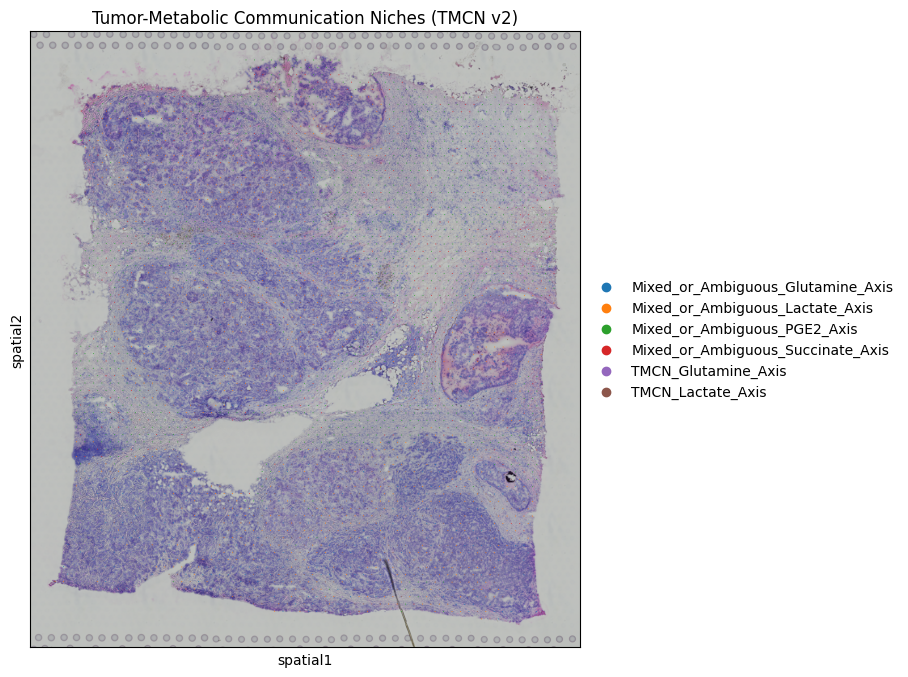

In [37]:
# 图 1：只画“正式标签”，Mixed 全部设成背景
adata_model.obs["TMCN_Niche_v2_clean"] = adata_model.obs["TMCN_Niche_v2"].astype(str)

mask_mixed = adata_model.obs["TMCN_Niche_v2_clean"].str.startswith("Mixed_or_Ambiguous")
adata_model.obs.loc[mask_mixed, "TMCN_Niche_v2_clean"] = "Background/Other_Niche"

adata_model.obs["TMCN_Niche_v2_clean"] = pd.Categorical(
    adata_model.obs["TMCN_Niche_v2_clean"]
)
plt.rcParams["figure.figsize"] = (9, 9)

sc.pl.spatial(
    adata_model,
    color="TMCN_Niche_v2_clean",
    spot_size=45,
    title="TMCN v2 (clean labels only)",
    palette=[
        "#d9d9d9",  # Background
        "#d62728",  # TMCN_Lactate_Axis
        "#9467bd",  # TMCN_Glutamine_Axis
    ],
    show=True,
)

In [ ]:
# 保存结果
save_path = file_path.replace(".h5ad", "_TMCN_HVG2000_FinalAnnotated_v2.h5ad")
adata_model.write_h5ad(save_path)

print("结果保存到：", save_path)